Earth Observation

Q1. Spatial Reasoning & Data Filtering

Understanding datasets:

1) Shapefile of the Delhi-NCR Region (EPSG:4326)
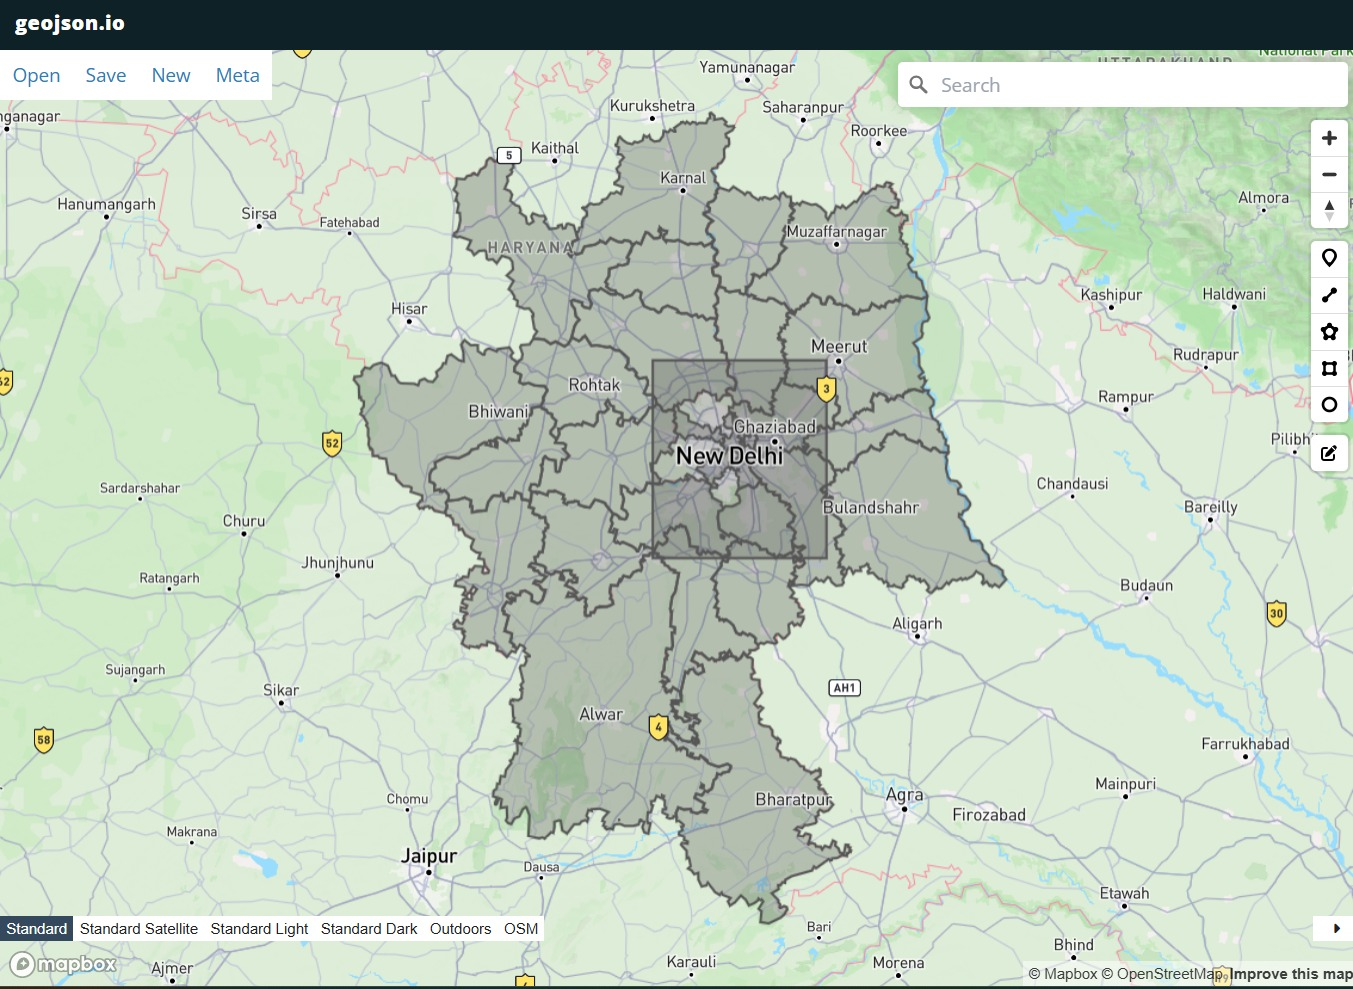

2)Sentinel-2 RGB image patches

Small satellite photos taken from Sentinel-2.

What each image contains:

1 Size: 128 × 128 pixels

2 Resolution: 10 meters per pixel

3 Covers about 1.28 km × 1.28 km area on the ground

4 RGB = looks like a normal color photo

Extra information:

1 Each image filename is linked to:

2 Latitude

3 Longitude
(the center point of the image)

Why it is needed:

1 These images are the inputs to your AI model

2 The model learns to identify what kind of land is visible

3) Shapefile of the Delhi-Airshed region  
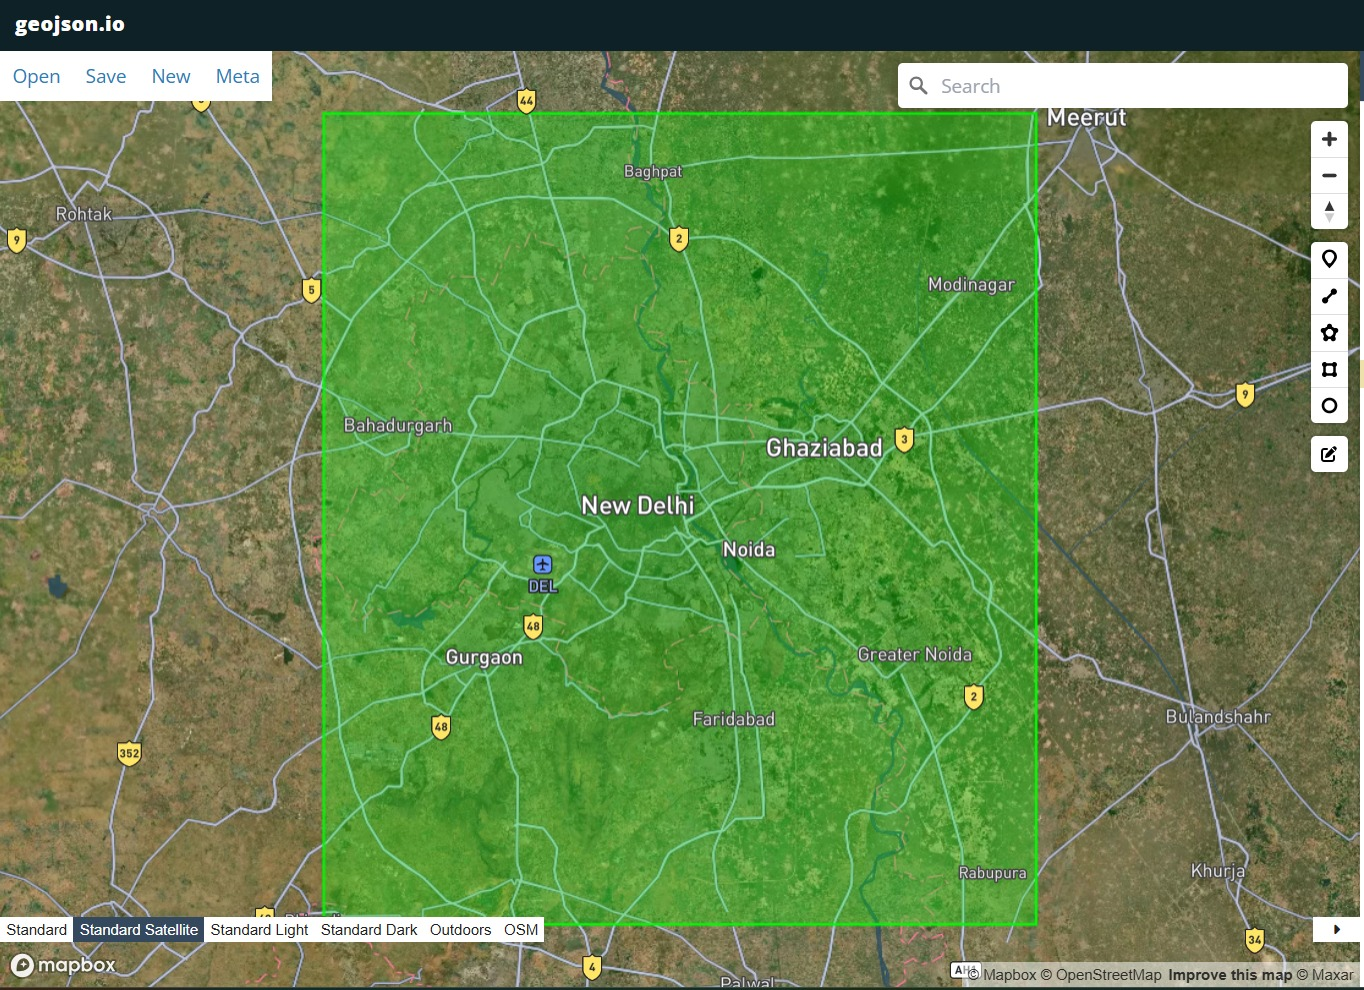

4) A land_cover.tif raster (ESA WorldCover 2021, 10m resolution)

A color-coded map that tells what type of land exists at every location.


In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import box
import geemap


Step 1: Plot Delhi-NCR shapefile and add a 60×60 km grid

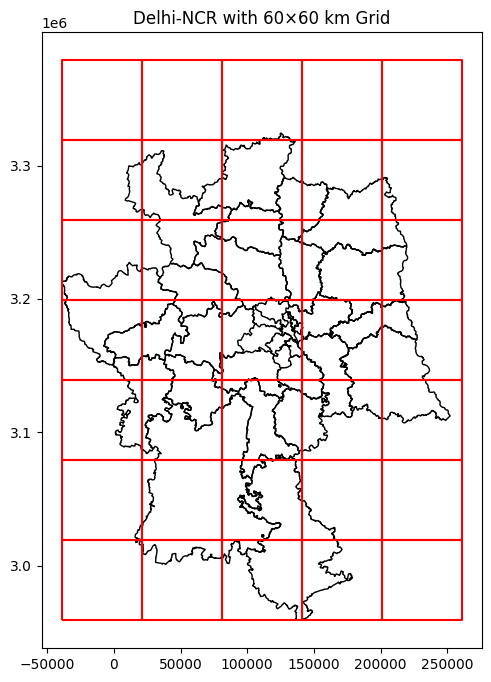

In [ ]:
# Load Delhi-NCR boundary (GeoJSON works same as shapefile)
delhi = gpd.read_file("delhi_ncr_region.geojson")

# Convert to meter-based CRS so 60 km is meaningful
delhi = delhi.to_crs(epsg=32644)

# Get boundary limits
xmin, ymin, xmax, ymax = delhi.total_bounds

# Grid size = 60 km
grid_size = 60000

# Create grid cells
cells = []
for x in np.arange(xmin, xmax, grid_size):
    for y in np.arange(ymin, ymax, grid_size):
        cells.append(box(x, y, x + grid_size, y + grid_size))

grid = gpd.GeoDataFrame(geometry=cells, crs="EPSG:32644")

# Plot Delhi-NCR + grid
delhi.plot(figsize=(8,8), edgecolor="black", color="none")
grid.boundary.plot(ax=plt.gca(), color="red")
plt.title("Delhi-NCR with 60×60 km Grid")
plt.show()


STEP 2: Overlay grid on satellite basemap

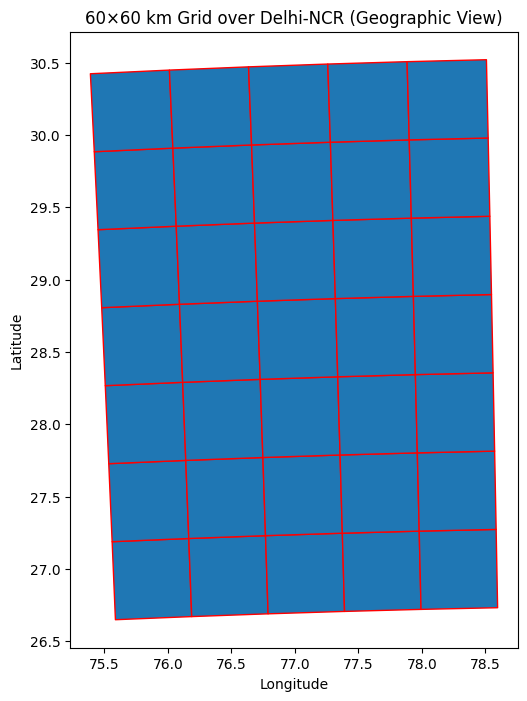

In [ ]:
import matplotlib.pyplot as plt

# Plot grid in geographic coordinates
grid.to_crs(epsg=4326).plot(
    figsize=(8,8),
    edgecolor="red",
    linewidth=1
)

plt.title("60×60 km Grid over Delhi-NCR (Geographic View)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


STEP 3: Mark four corners and center of each grid cell

<Figure size 600x600 with 0 Axes>

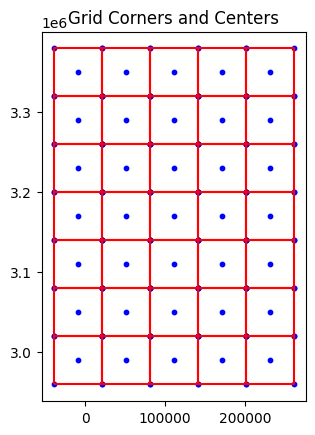

In [ ]:
xs, ys = [], []

for cell in grid.geometry:
    minx, miny, maxx, maxy = cell.bounds

    # four corners
    xs += [minx, minx, maxx, maxx]
    ys += [miny, maxy, miny, maxy]

    # center
    xs.append((minx + maxx) / 2)
    ys.append((miny + maxy) / 2)

plt.figure(figsize=(6,6))
grid.boundary.plot(color="red")
plt.scatter(xs, ys, color="blue", s=10)
plt.title("Grid Corners and Centers")
plt.show()


STEP 4: Filter images based on center coordinates

In [ ]:
import zipfile

with zipfile.ZipFile("rgb.zip", "r") as z:
    z.extractall("/content")


In [ ]:
import os
print(os.listdir("/content/rgb"))


['28.2354_76.9443.png', '28.4766_77.4443.png', '28.8354_77.0443.png', '28.8855_77.3646.png', '28.7442_77.1234.png', '28.6091_77.3321.png', '28.8943_77.0234.png', '28.5267_76.9910.png', '28.2354_77.2234.png', '28.3556_77.2410.png', '28.6091_77.1410.png', '28.6766_77.1058.png', '28.6355_76.9944.png', '28.3943_76.9321.png', '28.8057_77.2234.png', '28.6557_77.4057.png', '28.4354_77.0234.png', '28.6443_77.3444.png', '28.8266_77.0645.png', '28.7767_76.9910.png', '28.7442_77.0234.png', '28.3354_76.9233.png', '28.6854_77.1234.png', '28.8943_77.5443.png', '28.6443_76.9321.png', '28.9766_77.5058.png', '28.7943_77.5557.png', '28.8057_77.4057.png', '28.5678_76.9822.png', '28.3855_76.9646.png', '28.5766_77.1058.png', '28.6557_77.1557.png', '28.9442_77.4443.png', '28.3767_77.0410.png', '28.7056_77.6146.png', '28.7056_76.9409.png', '28.3178_77.3233.png', '28.9266_77.0443.png', '28.6443_76.9822.png', '28.2056_77.5234.png', '28.9442_77.4910.png', '28.9266_77.5322.png', '28.7679_77.0821.png', '28.8556_7

In [ ]:
import os
from shapely.geometry import Point

image_folder = "rgb"
points = []

for file in os.listdir(image_folder):
    if file.endswith(".png"):
        parts = file.replace(".png", "").split("_")
        lat = float(parts[-2])
        lon = float(parts[-1])
        points.append(Point(lon, lat))

# Convert image points to GeoDataFrame
images = gpd.GeoDataFrame(geometry=points, crs="EPSG:4326")
images = images.to_crs(epsg=32644)

# Filter images inside grid
filtered_images = images[images.within(grid.unary_union)]


/tmp/ipython-input-2645311038.py:19: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  filtered_images = images[images.within(grid.unary_union)]


STEP 5: Count images before and after filtering

In [ ]:
print("Images before filtering:", len(images))
print("Images after filtering:", len(filtered_images))


Images before filtering: 9216
Images after filtering: 9216


Q2. Label Construction & Dataset Preparation

STEP 1: Extract 128×128 land-cover patch for each image

In [ ]:
import rasterio
import numpy as np

raster_path = "worldcover_bbox_delhi_ncr_2021.tif"

patches = []

with rasterio.open(raster_path) as src:
    for point in filtered_images.geometry:
        x, y = point.x, point.y

        # Convert coordinates to raster row, col
        row, col = src.index(x, y)

        # Extract 128×128 window centered at point
        window = rasterio.windows.Window(col-64, row-64, 128, 128)
        patch = src.read(1, window=window)

        patches.append(patch)


STEP 2: Assign label using mode (most frequent class)

In [ ]:
labels = []

for patch in patches:
    values = patch.flatten()
    values = values[values != 0]   # remove no-data

    if len(values) == 0:
        labels.append(-1)
    else:
        labels.append(np.bincount(values).argmax())


STEP 3: Map ESA class codes to 11 standardized labels

In [ ]:
ESA_MAP = {
    10: "Tree Cover",
    20: "Shrubland",
    30: "Grassland",
    40: "Cropland",
    50: "Built-up",
    60: "Bare / Sparse",
    70: "Snow / Ice",
    80: "Water",
    90: "Wetlands",
    95: "Mangroves",
    100: "Moss / Lichen"
}

final_labels = [ESA_MAP.get(l, "Unknown") for l in labels]


STEP 4: Handle edge cases

In [ ]:
valid_data = [(p, l) for p, l in zip(patches, final_labels) if l != "Unknown"]

patches, final_labels = zip(*valid_data)


ValueError: not enough values to unpack (expected 2, got 0)

Q3. Model Training & Supervised Evaluation

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import numpy as np


STEP 1: Encode labels + Dataset class

In [ ]:
# Encode labels to integers
classes = sorted(list(set(y_train)))
class_to_idx = {c: i for i, c in enumerate(classes)}

y_train_enc = [class_to_idx[c] for c in y_train]
y_test_enc  = [class_to_idx[c] for c in y_test]


NameError: name 'y_train' is not defined